### Setup

To begin the project, I loaded the **red and white wine datasets** (from their CSV files in directory `datasets/`), which contain properties and quality scores for different wines.

I also used plot styling with Seaborn to ensure clean visuals and easy plot readability/interprebility throughout the notebook.

In [15]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
wine_red = pd.read_csv("../datasets/winequality-red.csv",sep=";")
wine_white = pd.read_csv("../datasets/winequality-white.csv",sep=";")
wine_red.columns = wine_red.columns.str.strip()
wine_white.columns = wine_white.columns.str.strip()

# Set global style
sns.set_theme(style="whitegrid", font_scale=1.2)
palette_red = sns.color_palette("Reds_r", as_cmap=True)
palette_white = sns.color_palette("Blues", as_cmap=True)

### Task 1A: Wine Quality Comparison (Red vs White)

Below is a side-by-side plot comparing quality scores for both datasets. The white wine dataset (4,898 samples) is more than three times the size of the red wine dataset (1,599 samples) and therefore has a higher y-axis.

**Comparison:**
- Both wines have median scores of around **5 and 6**.
- **Red wine** is **highly focused** around these mid-scores, with almost no wines above score 7 (narrower spread).
- **White wine** quality has a **wider range**, with more highly ranking wines (7–9) and a longer right tail (more dispersed).


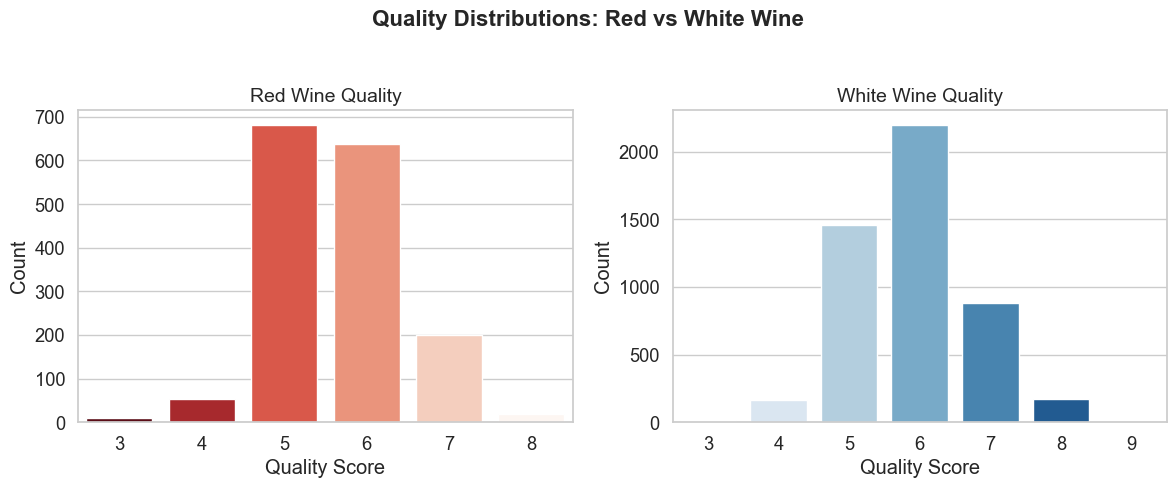

In [2]:
# Plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Red plot
sns.countplot(data=wine_red, x="quality", hue="quality",ax=axes[0],palette="Reds_r",legend=False)
axes[0].set_title("Red Wine Quality",fontsize=14)
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Count")

# White plot
sns.countplot(data=wine_white, x="quality",hue="quality",ax=axes[1],palette="Blues",legend=False)
axes[1].set_title("White Wine Quality",fontsize=14)
axes[1].set_xlabel("Quality Score")
axes[1].set_ylabel("Count")

# Both plot
plt.suptitle("Quality Distributions: Red vs White Wine", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figures/wine_quality_comparison.png", dpi=300)
plt.show()

### Red Wine Quality Distribution

This plot shows red wine quality ratings independently.

**Quality Plot Analysis:**
- Most red wine qualities are rated either **5 or 6**, with not many wines outside of this range.
- Few wines exist with quality scores of **3, 4, 7, or 8**, and there are none with a score of **9**.
- The distribution is **unimodal** and suggests **low quality variance**.

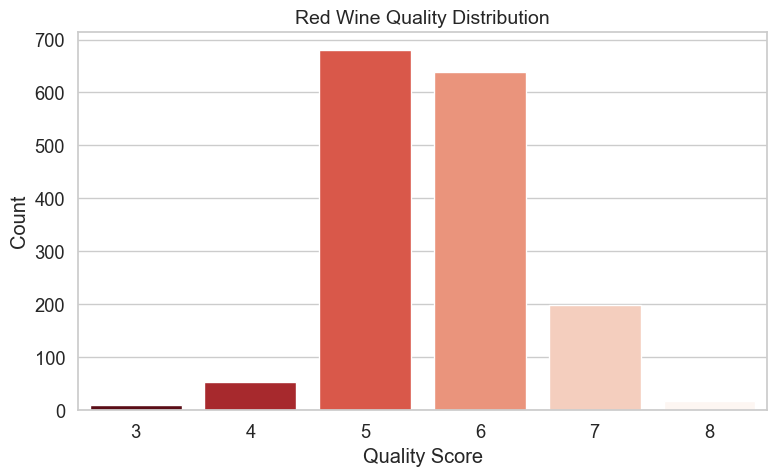

In [3]:
# Red wine plot
plt.figure(figsize=(8, 5))
sns.countplot(data=wine_red, x="quality", hue="quality", palette="Reds_r", legend=False)
plt.title("Red Wine Quality Distribution", fontsize=14)
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/red_wine_quality.png", dpi=300)
plt.show()

### White Wine Quality Distribution

The white wine dataset, when plotted against quality, is considerably different.

**Quality Plot Analysis:**
- The mode is the same as red wine, at **6**, but the distribution is **broader** and includes higher ratings including **9**, unlike the red wine plot.
- White wines rated **7 or 8** are not uncommon, and a few wines score at **9**.
- Lower scores (**3, 4**) are also more frequent than in the red wines dataset.

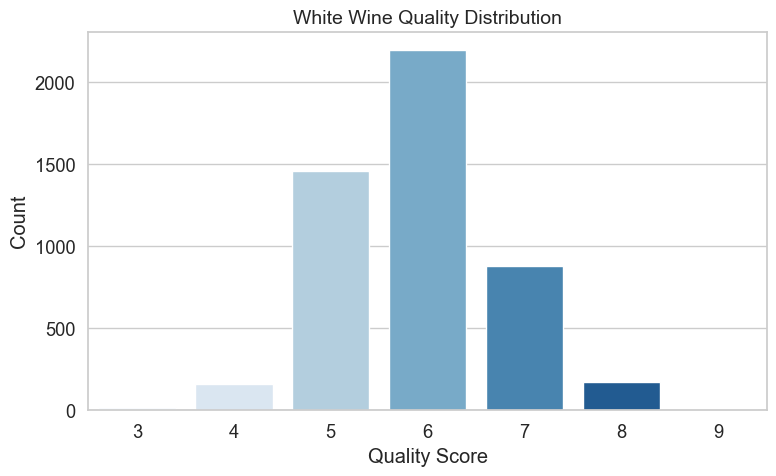

In [4]:
# White wine plot
plt.figure(figsize=(8, 5))
sns.countplot(data=wine_white, x="quality", hue="quality", palette="Blues", legend=False)
plt.title("White Wine Quality Distribution", fontsize=14)
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/white_wine_quality.png", dpi=300)
plt.show()

## End: Task 1A

### Summary

- Red wine quality is tightly clustered around scores 5 and 6.
- White wine quality has a larger spread, with more highly-rated samples (7 and 8), and a longer right tail.
- There are over 3x as many white wine samples as there are red.

## Begin Task 1B

### Discretise Alcohol Content Vars. Based on Distribution

To investigate how alcohol content influenced wine quality, I discretised alcohol content separately on whites and reds into a three valued variable (`alcohol_cat`) based on distribution:

- **low**: alcohol < (mean - stddev)
- **mid**: (mean - stddev) < alcohol < (mean + stddev)
- **high**: alcohol > (mean + stddev)

To do this, I made a helper function to calculate the dataset’s mean and standard deviation (`stddev`), and assigned each sample to one of the three categories.

In [18]:
def add_alcohol_category(df):
    mean = df["alcohol"].mean()
    stddev = df["alcohol"].std()
    
    def categorise(alc):
        if alc < mean - stddev:
            return "low"
        elif alc > mean + stddev:
            return "high"
        else:
            return "mid"
    
    return df.assign(alcohol_cat=df["alcohol"].apply(categorise))

### Generating Red Wine Quality Plot *by Alcohol Category*

The boxplot below displays the relationship between red wine quality and `alcohol_cat` (low, mid, high).

**Observations:**
- A clear positive trend is shown across alcohol categories: this suggests **higher alcohol content is associated with higher quality scores**.
- The **median quality** increases from 5 (low) to 6 (mid), and 7 (high).
- The **spread** of quality scores *narrows* for the high alcohol group, indicating that there is higher consistent quality among red wines with higher alcohol content.
- Red wines in the low alcohol cat rarely achieve ratings above 6, and show more low outliers.

**Why?:**
- Alcohol seems to be influential to the quality of the red wines.
- Thus the category `alcohol_cat` provides **meaningful stratification/classification** of quality and should be considered a possible feature in later predictive modelling.

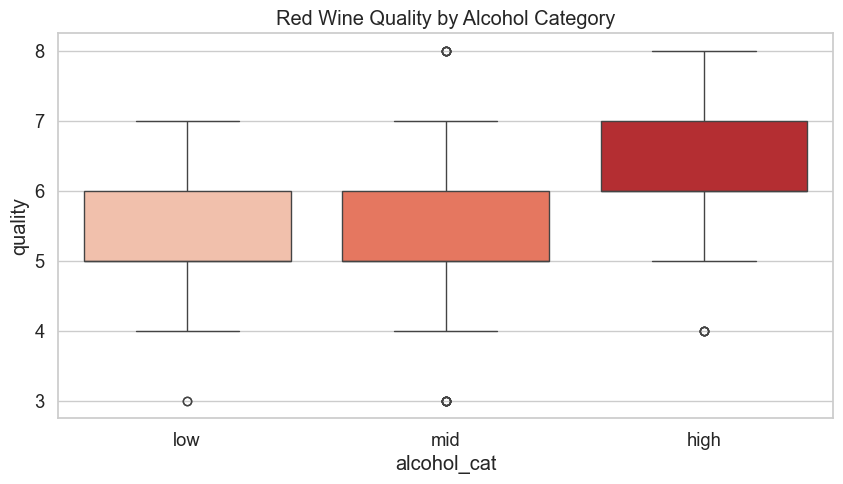

In [27]:
# Apply to both datasets
wine_red = add_alcohol_category(wine_red)
wine_white = add_alcohol_category(wine_white)

# Red wine
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=wine_red,
    x="alcohol_cat",
    y="quality",
    palette="Reds",
    hue="alcohol_cat",
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"]
)
plt.title("Red Wine Quality by Alcohol Category")
plt.savefig("../figures/red_quality_by_alcohol.png")
plt.show()

### White Wine Quality by Alcohol Category

The following boxplot shows how white wine quality varies across the same `alcohol_cat` categories.

**Observations:**
- The same **positive correlation** seen in red wine also appears in white wine: higher alcohol levels tend to correspond with higher quality ratings.
- The **high alcohol group** has the highest median quality and includes most of the top-scoring wines (7–9).
- Low alcohol wines are more tightly clustered around scores of 5–6, with few high-quality outliers.
- Compared to red wine, the differences are slightly less dramatic, but still consistent.

**Interpretation:**
- Alcohol content is again a **strong quality indicator**, even in white wine — reinforcing its importance as a key physicochemical predictor.
- This consistent trend across both wine types suggests the `alcohol_cat` variable is **robust and generalisable**, making it especially valuable for model training across datasets.

**Next Steps:**
- When constructing classifiers or regressors, `alcohol_cat` could serve as a compact, interpretable input feature that captures one of the most predictive dimensions of the data.

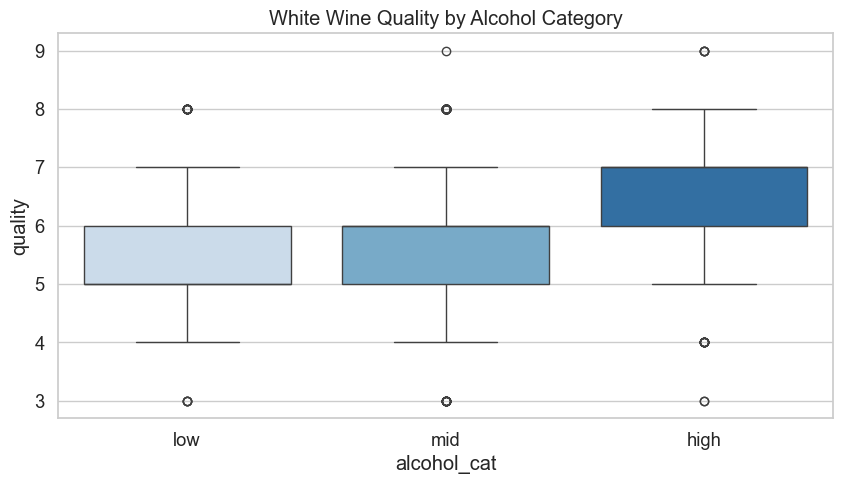

In [49]:
# White wine
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=wine_white,
    x="alcohol_cat",
    y="quality",
    palette="Blues",
    hue="alcohol_cat",
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"]
)
plt.title("White Wine Quality by Alcohol Category")
plt.savefig("../figures/white_quality_by_alcohol.png")
plt.show()

## End: Task 1B

### Summary

In Task 1B, I examined how alcohol content — a key physicochemical variable — relates to perceived wine quality across both red and white wines.

To do this, I engineered a new categorical feature, `alcohol_cat`, by discretising the continuous `alcohol` variable into three levels (low, mid, high) using each dataset’s mean and standard deviation. This approach aligns with the project specification and ensures a statistically meaningful classification that respects the underlying data distribution.

**Key Findings:**

- For both red and white wines, **higher alcohol content correlates with higher quality ratings**.
- The relationship is especially clear in red wines, where low-alcohol samples rarely exceed a rating of 6, while high-alcohol wines frequently achieve 7+.
- White wines show a similar, though slightly subtler, trend — reinforcing alcohol’s value as a general predictor of quality.
- The `alcohol_cat` variable provides **interpretable stratification** of quality and simplifies later classification tasks.

**Implications for Modelling:**

- The strength and consistency of the alcohol–quality relationship suggests this feature will be **highly useful in both regression and classification models**.
- Using a categorical representation like `alcohol_cat` (instead of raw alcohol values) also improves interpretability and may benefit algorithms that don’t naturally model continuous variables well (e.g., decision trees).

This task demonstrated that alcohol content is not only chemically relevant but also one of the clearest quality indicators in the dataset — providing strong groundwork for feature selection and model building in Task 3.

## Begin Task 1C

### isSweet



### Creating a Binary Sweetness Feature

Residual sugar is an important physicochemical characteristic in wine that contributes to its perceived sweetness. However, the distribution of residual sugar is **skewed** for both red and white wine datasets.

To investigate its effect on quality, we created a binary variable `isSweet`, defined as:
- `1` if residual sugar is **greater than or equal to** the median,
- `0` otherwise.

Using the **median** ensures a near-even split between sweet and dry classes, providing **balanced groups** for visualisation and future classification models. This approach aligns with the project brief's recommendation for practical and interpretable categorisation.

In [50]:
# Add is sweet category
def add_is_sweet(df):
    threshold = df["residual sugar"].median()
    return df.assign(isSweet=(df["residual sugar"] >= threshold).astype(int))


### Applying `isSweet` to Red and White Wines

Applied the transformation separately to red and white wine datasets to avoid introducing bias from differing sugar ranges between wine types.

This maintains internal consistency and supports fair comparisons, ensuring that 'sweetness' reflects each dataset's own distribution rather than a shared global threshold.

In [51]:
# Apply to both datasets
wine_red = add_is_sweet(wine_red)
wine_white = add_is_sweet(wine_white)

### Red Wine: Quality by Sweetness

The boxplots below shows how wine quality varies between dry (`isSweet = 0`) and sweet (`isSweet = 1`) red wines.

**Observations:**
- The **median quality is identical** for both groups (quality score = 6).
- Sweet red wines show **slightly wider variability**, with more outliers below the lower whisker.
- Overall, residual sugar **does not appear to be a strong differentiator** of red wine quality.
- This implies that **sweetness alone is not a reliable indicator of sensory quality** for red wine, though it may interact with other factors (like alcohol or acidity).

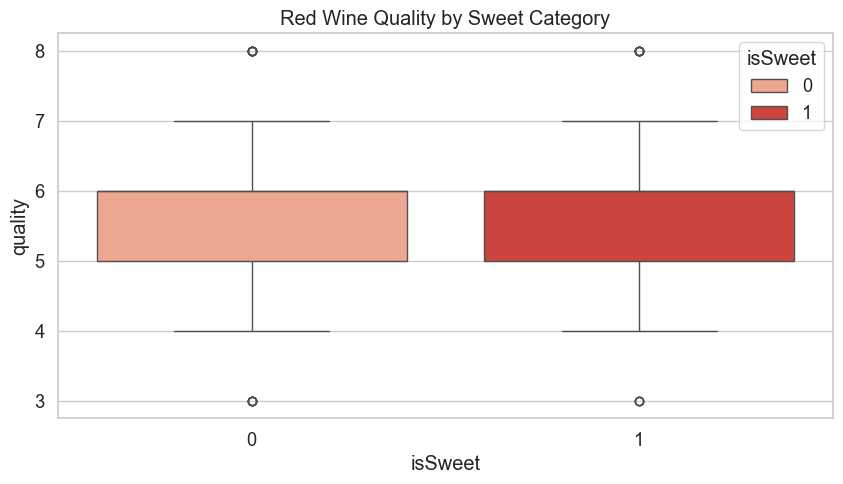

In [52]:
# Red wine by sweetness
plt.figure(figsize=(10, 5))
sns.boxplot(data=wine_red, x="isSweet", y="quality", palette="Reds", hue="isSweet")
plt.title("Red Wine Quality by Sweet Category")
plt.savefig("../figures/red_quality_by_sugar.png")
plt.show()

### White Wine: Quality by Sweetness

The same analysis was repeated for white wine, producing the following result:

**Observations:**
- In contrast to red wine, dry white wines (`isSweet = 0`) show a **higher median** and more upper-end quality scores.
- Sweet white wines are more tightly clustered and **rarely exceed a quality rating of 6**.
- This indicates a clearer trend: **dry white wines are more likely to be rated highly**, which aligns with expert tasting expectations.

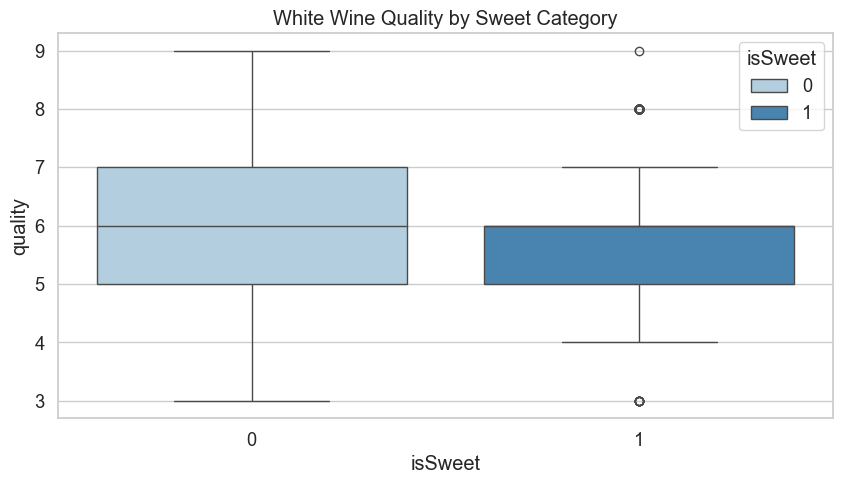

In [53]:
# White wine by sweetness
plt.figure(figsize=(10, 5))
sns.boxplot(data=wine_white, x="isSweet", y="quality", palette="Blues", hue="isSweet")
plt.title("White Wine Quality by Sweet Category")
plt.savefig("../figures/white_quality_by_sugar.png")
plt.show()

### Summary: Task 1C Findings

- Created a balanced `isSweet` feature based on the median residual sugar for each wine type.
- Sweetness shows **little correlation with quality** in red wine, but a **clear negative trend** in white wine.
- For modelling:
  - `isSweet` may not be a useful feature for red wine prediction on its own.
  - However, it could improve classification performance for white wines when used in combination with other attributes.


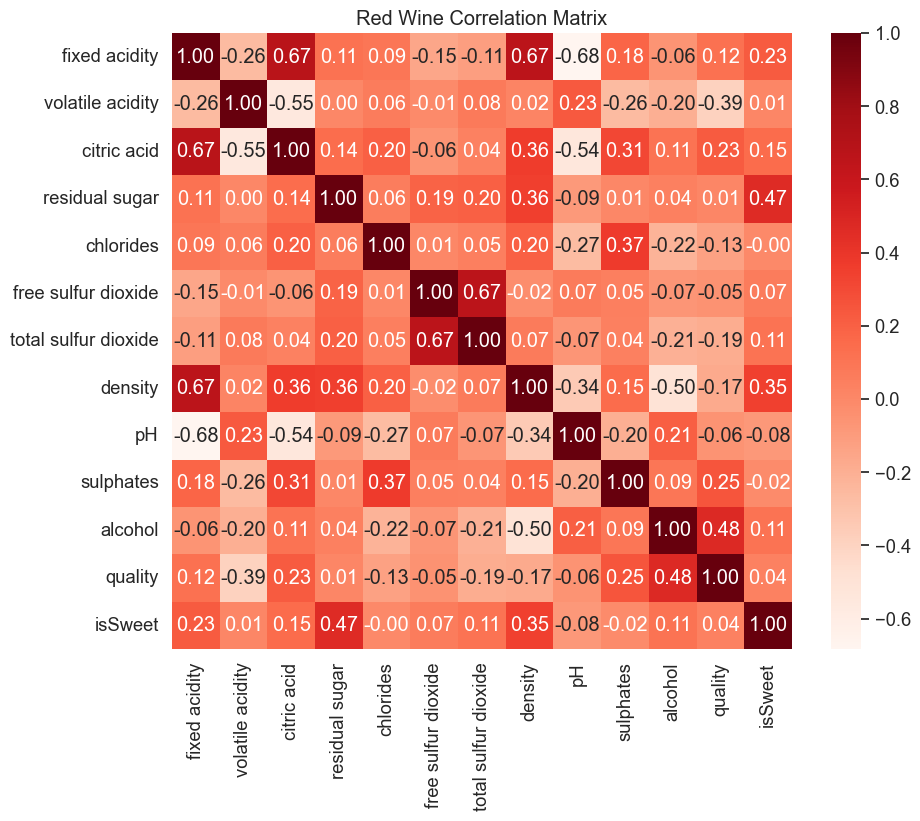

In [54]:
corr_red = wine_red.corr(numeric_only=True, method='pearson')
corr_white = wine_white.corr(numeric_only=True, method='pearson')

# Heatmap red

plt.figure(figsize=(10, 8))
sns.heatmap(corr_red, annot=True, cmap="Reds", fmt=".2f")
plt.title("Red Wine Correlation Matrix")
plt.show()


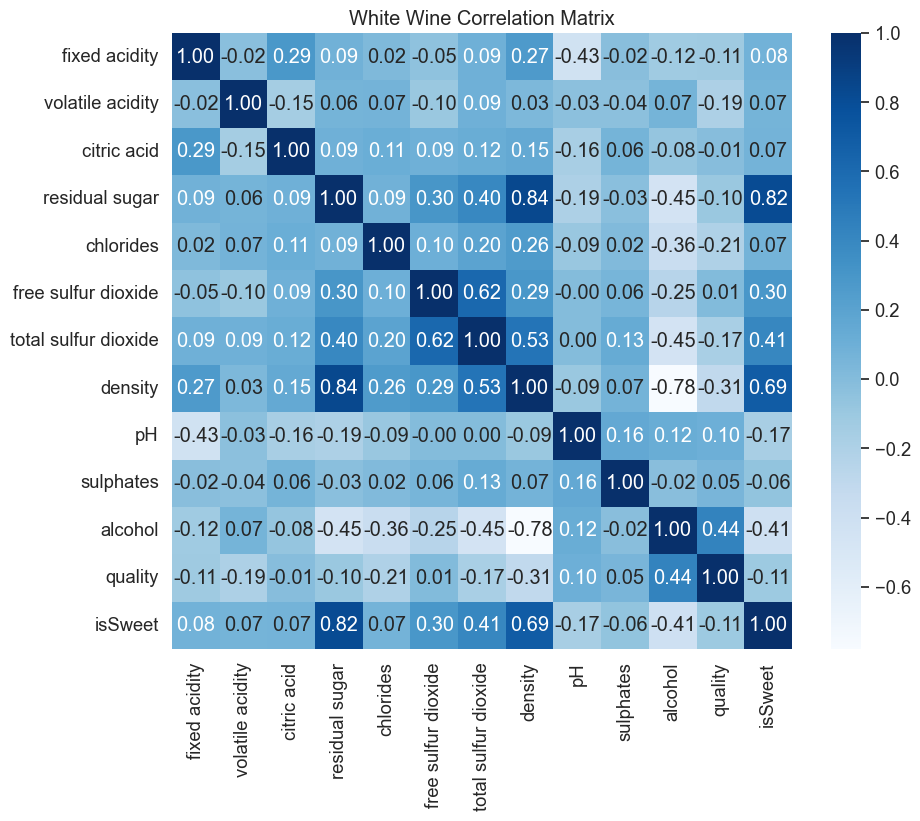

In [55]:
# Heatmap white

plt.figure(figsize=(10, 8))
sns.heatmap(corr_white, annot=True, cmap="Blues", fmt=".2f")
plt.title("White Wine Correlation Matrix")
plt.show()